# Stored vs. New CBSS Calibration for Adaptive EMG Decomposition

Compares two calibration strategies on a real forearm HD-EMG staircase recording:

| Path | Calibration source | Unit selection |
|------|-------------------|----------------|
| **A — Stored** | Pre-computed CBSS `.h5` from the isometric phase | All units (no filtering) |
| **B — New** | `calibrate_from_indices()` re-runs CBSS on the same iso window | `select_units_supervised()` keeps units with RoA ≥ 0.9 vs. stored iso spikes |

Both calibrations are then fed into `AdaptDecomp` for the full staircase recording and compared.

## 0. Setup

In [1]:
import sys
from pathlib import Path

REPO     = Path('..', '..', '..').resolve()  # tutorials -> adapt_decomp -> lib -> repo root
SRC      = REPO / 'src'
LIB_ADAPT = REPO / 'lib' / 'adapt_decomp' / 'src'
for p in (SRC, LIB_ADAPT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp import CBSSConfig, calibrate_from_indices, select_units_supervised

from decomposition.cbss.io import load_decomposition_result
from decomposition.loaders.loaders import load_all

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = dict(no_adapt='tab:orange', adapt='tab:blue')

plt.rcParams.update({'figure.dpi': 100})

2026-06-16 08:40:55.388 | INFO     | decomposition.config:<module>:11 - PROJ_ROOT path is: C:\Users\Irene\Documents\work_local\decomposition\src


## 1. Load data

In [2]:
# ---- paths ----
SUBJ     = 'sub1'
LOC      = 'forearm'
TASK     = 'staircase_ext_1_index_15MVC'
BASE     = f'{SUBJ}_{LOC}_{TASK}'

MAT_PATH   = REPO / 'data' / 'raw' / 'prepro_data_formatted' / LOC / SUBJ / f'{SUBJ}_{TASK}_prepro_data_{LOC}.mat'
DECOMP_ROOT = REPO / 'data' / 'processed' / 'decomp_full_from_iso0'
ISO_DECOMP_PATH = DECOMP_ROOT / f'{BASE}_iso_0'

# ---- raw EMG ----
data       = load_all(MAT_PATH)
emg_pre    = data['emg']          # [T, C] numpy float32
timestamps = data['timestamps']   # [T] numpy
fs         = int(data['fs'])
ch_map     = data['ch_map']

n_samples, n_chs = emg_pre.shape
ext_fact = 1000 // n_chs
print(f'Recording:  {n_samples} samples  ({n_samples/fs:.1f} s)  |  {n_chs} ch  |  fs={fs} Hz')
print(f'ext_fact:   {ext_fact}')

# ---- isometric phase (1-indexed in mat, convert to Python) ----
phases     = data['phases']
iso_bounds = phases[0, 0][0]           # all iso phases  [n_iso, 2]
py_start   = int(iso_bounds[0, 0]) - 1  # first iso phase start
py_end     = int(iso_bounds[0, 1])      # first iso phase end (exclusive in Python)
iso_slice  = slice(py_start, py_end)

print(f'Iso phase:  samples {py_start}–{py_end}  ({(py_end-py_start)/fs:.1f} s)')

Recording:  134134 samples  (65.5 s)  |  192 ch  |  fs=2048 Hz
ext_fact:   5
Iso phase:  samples 0–11282  (5.5 s)


In [ ]:

data.keys()

dict_keys(['emg', 'timestamps', 'ch_map', 'fs', 'phases', 'rms', 'angle', 'force', 'angle_cue', 'force_cue'])

In [6]:
stored_result, stored_cfg = load_decomposition_result(ISO_DECOMP_PATH)
stored = stored_result.to_dict()

stored.keys()
stored['sources'].shape, stored['spikes'].shape

((11282, 18), (11282, 18))

## 2. Path A — Stored calibration

Load the CBSS result from the pre-computed `.h5` file and build `AdaptDecomp` directly.

In [15]:
stored_result, stored_cfg = load_decomposition_result(ISO_DECOMP_PATH)
stored = stored_result.to_dict()

print(f'Stored calibration: {stored["sources"].shape[1]} units')
print(f'  SIL  {stored["sil"].mean():.3f} ± {stored["sil"].std():.3f}')
print(f'  CoV  {stored["cov"].mean():.3f} ± {stored["cov"].std():.3f}')
print(f'  PNR  {stored["pnr"].mean():.1f} ± {stored["pnr"].std():.1f}')
print(f'  DR   {stored["dr"].mean():.1f} ± {stored["dr"].std():.1f}')
print(f'  emg stored: {stored["emg"] is not None}')

Stored calibration: 18 units
  SIL  0.963 ± 0.022
  CoV  0.428 ± 0.379
  PNR  25.8 ± 8.2
  DR   13.6 ± 5.0
  emg stored: False


In [16]:
def make_adapt_config(ext_fact: int, *, adapt: bool, log_loss: bool = True) -> Config:
    cfg = Config()
    cfg.ext_fact       = ext_fact
    cfg.log_loss       = log_loss
    cfg.device         = 'cpu'
    cfg.contrast_scope = 'spike_based'
    cfg.wh_mode        = 'kl_to_cal'
    cfg.batch_ms       = 100
    if not adapt:
        cfg.adapt_wh = False
        cfg.adapt_sv = False
        cfg.adapt_sd = False
    return cfg


# The stored iso result was saved without emg — provide the raw iso window instead
emg_calib_np = emg_pre[iso_slice].astype(np.float32)   # [T_iso, C]

def run_stored(adapt: bool):
    cfg = make_adapt_config(ext_fact, adapt=adapt)
    dec = AdaptDecomp(
        emg             = torch.from_numpy(emg_pre.astype(np.float32)),
        whitening       = torch.from_numpy(stored['whitening']),
        sep_vectors     = torch.from_numpy(stored['sep_vectors'].T),
        base_centroids  = torch.from_numpy(stored['base_centr']),
        spike_centroids = torch.from_numpy(stored['spikes_centr']),
        emg_calib       = torch.from_numpy(emg_calib_np),
        ipts_calib      = torch.from_numpy(stored['sources']),
        spikes_calib    = torch.from_numpy(stored['spikes']).to(torch.int32),
        preprocess      = False,
        config          = cfg,
    )
    return dec.run()

out_a_no  = run_stored(adapt=False)
print(f'[A / no-adapt]  done  |  units: {out_a_no["ipts"].shape[1]}')
out_a     = run_stored(adapt=True)
print(f'[A / adapt]     done  |  units: {out_a["ipts"].shape[1]}')

[A / no-adapt]  done  |  units: 18
[A / adapt]     done  |  units: 18


## 3. Path B — New CBSS calibration + supervised unit selection

`calibrate_from_indices()` re-runs the full CBSS pipeline on the iso window.  
`select_units_supervised()` keeps only units whose spike train matches a **stored** unit with **RoA ≥ 0.9**,  
and records the matched stored-unit index in `result.gt_matched_indices`.

In [17]:
cbss_config = CBSSConfig(
    fs             = float(fs),
    ext_fact       = ext_fact,
    preprocess_emg = False,    # data is already bandpass-filtered
    save_emg       = True,     # required by from_calibration()
    sil_th         = 0.9,
    search_iter    = 500,
    ica_iter       = 500,
    spike_min_dist_ms = 10.0,
    spike_det_exp  = 2.0,
    contrast_fun   = 'smooth_abs',
    contrast_exp   = 3.0,
    compute_properties = True,
    random_seed    = 0,
    ch_map         = ch_map,
    device         = 'cpu',
)

print('Running CBSS on iso window …')
new_result = calibrate_from_indices(
    emg          = emg_pre,
    timestamps   = timestamps,
    calib_indices= iso_slice,
    cbss_config  = cbss_config,
)
n_new = new_result.sources.shape[1]
print(f'CBSS found {n_new} units before selection')
print(f'  SIL  {new_result.sil.mean():.3f} ± {new_result.sil.std():.3f}')
print(f'  CoV  {new_result.cov.mean():.3f} ± {new_result.cov.std():.3f}')
if new_result.pnr is not None:
    print(f'  PNR  {new_result.pnr.mean():.1f} ± {new_result.pnr.std():.1f}')

Running CBSS on iso window …
CBSS found 16 units before selection
  SIL  0.964 ± 0.024
  CoV  0.409 ± 0.353
  PNR  26.5 ± 8.4


In [18]:
ROA_TH = 0.9

# GT = stored iso decomp spikes aligned to the same iso window
# stored['spikes'] shape: [T_iso, n_stored]
gt_spikes_iso = stored['spikes'].astype(np.int32)   # [T_iso, n_stored]

selected = select_units_supervised(
    new_result,
    gt_spikes_iso,
    roa_th = ROA_TH,
    tol_ms = 0.5,
    fs     = float(fs),
)

n_sel = selected.sources.shape[1]
print(f'Units after supervised selection (RoA ≥ {ROA_TH}):  {n_sel} / {n_new}')
print(f'Matched stored-unit indices:  {selected.gt_matched_indices}')

Units after supervised selection (RoA ≥ 0.9):  2 / 16
Matched stored-unit indices:  [9 0]


### 3.1 Unit matching summary

In [19]:
from adapt_decomp.cbss.comparison import rate_of_agreement_pair

tol_spike = max(1, round(0.5e-3 * fs))
dec_sp = torch.as_tensor(selected.spikes.astype(np.int32))   # [T_iso, n_sel]
gt_sp  = torch.as_tensor(gt_spikes_iso)                       # [T_iso, n_stored]

rows = []
for i, gt_idx in enumerate(selected.gt_matched_indices):
    roa_val, _ = rate_of_agreement_pair(
        dec_sp[:, i].bool(), gt_sp[:, int(gt_idx)].bool(), tol_spike, 0
    )
    rows.append(dict(
        new_unit   = i,
        stored_unit= int(gt_idx),
        RoA        = float(roa_val),
        SIL        = float(selected.sil[i]),
        CoV        = float(selected.cov[i]),
        PNR        = float(selected.pnr[i]) if selected.pnr is not None else float('nan'),
    ))

hdr = f'  {"new":>4}  {"stored":>7}  {"RoA":>6}  {"SIL":>6}  {"CoV":>6}  {"PNR":>6}'
print(hdr)
print('-' * len(hdr))
for r in rows:
    print(f"  {r['new_unit']:>4}  {r['stored_unit']:>7}  {r['RoA']:>6.3f}  {r['SIL']:>6.3f}  {r['CoV']:>6.3f}  {r['PNR']:>6.1f}")

   new   stored     RoA     SIL     CoV     PNR
-----------------------------------------------
     0        9   1.000   0.982   0.103    32.9
     1        0   0.982   0.964   0.123    26.2


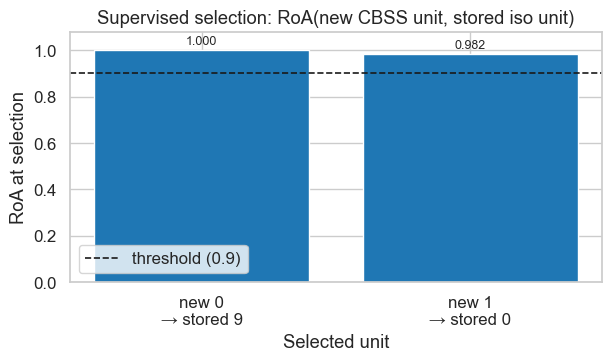

In [20]:
roa_vals    = [r['RoA'] for r in rows]
unit_labels = [f"new {r['new_unit']}\n→ stored {r['stored_unit']}" for r in rows]

fig, ax = plt.subplots(figsize=(max(6, n_sel * 1.4), 3.5), layout='constrained')
bars = ax.bar(unit_labels, roa_vals, color='tab:blue', edgecolor='white')
ax.axhline(ROA_TH, color='k', linestyle='--', linewidth=1.2, label=f'threshold ({ROA_TH})')
ax.set(ylabel='RoA at selection', ylim=(0, 1.08),
       xlabel='Selected unit', title='Supervised selection: RoA(new CBSS unit, stored iso unit)')
ax.legend()
ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=9)
plt.show()

### 3.2 Quality metrics: new CBSS vs. stored

C:\Users\Irene\AppData\Local\Temp\ipykernel_6504\2128869723.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='source', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\ipykernel_6504\2128869723.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='source', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\ipykernel_6504\2128869723.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='source', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\

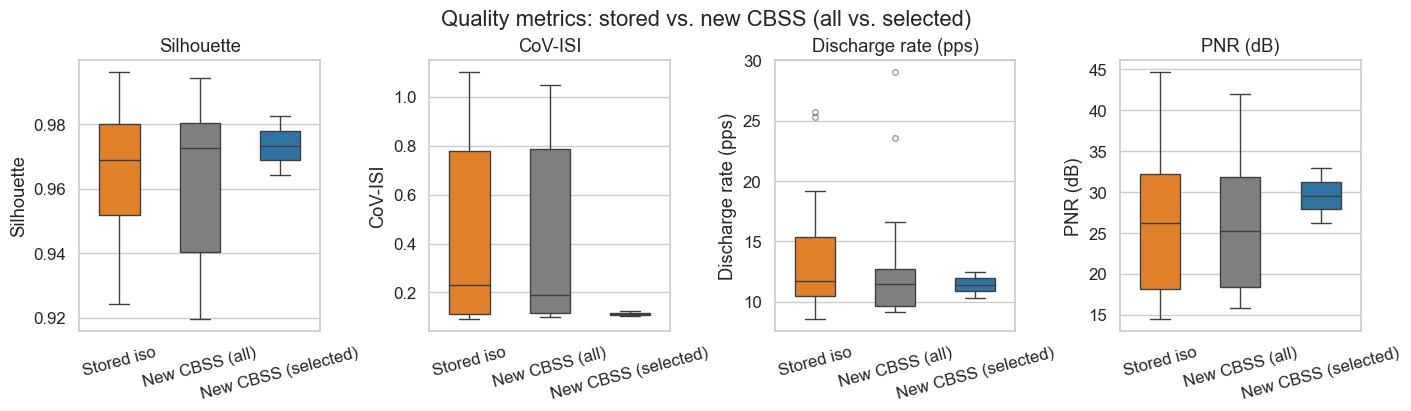

In [21]:
import pandas as pd

rows_a = [dict(source='Stored iso',  unit=i, SIL=stored['sil'][i],   CoV=stored['cov'][i],
               DR=stored['dr'][i],   PNR=stored['pnr'][i])
          for i in range(stored['sources'].shape[1])]

rows_b = [dict(source='New CBSS (all)',    unit=i, SIL=new_result.sil[i], CoV=new_result.cov[i],
               DR=new_result.dr[i] if new_result.dr is not None else float('nan'),
               PNR=new_result.pnr[i] if new_result.pnr is not None else float('nan'))
          for i in range(new_result.sources.shape[1])]

rows_c = [dict(source='New CBSS (selected)', unit=i, SIL=selected.sil[i], CoV=selected.cov[i],
               DR=selected.dr[i] if selected.dr is not None else float('nan'),
               PNR=selected.pnr[i] if selected.pnr is not None else float('nan'))
          for i in range(n_sel)]

df = pd.concat([pd.DataFrame(r) for r in [rows_a, rows_b, rows_c]], ignore_index=True)

palette = {'Stored iso': 'tab:orange', 'New CBSS (all)': 'tab:grey', 'New CBSS (selected)': 'tab:blue'}
order   = ['Stored iso', 'New CBSS (all)', 'New CBSS (selected)']

fig, axes = plt.subplots(1, 4, figsize=(14, 4), layout='constrained')
for ax, col, ylabel in zip(axes, ['SIL', 'CoV', 'DR', 'PNR'],
                            ['Silhouette', 'CoV-ISI', 'Discharge rate (pps)', 'PNR (dB)']):
    sns.boxplot(data=df, x='source', y=col, order=order, palette=palette,
                ax=ax, width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5))
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Quality metrics: stored vs. new CBSS (all vs. selected)')
plt.show()

### 3.3 Run adaptation from new calibration

In [22]:
def run_new(adapt: bool):
    cfg = make_adapt_config(ext_fact, adapt=adapt)
    dec = AdaptDecomp.from_calibration(
        emg         = emg_pre,      # full recording (numpy OK, from_calibration converts)
        calibration = selected,
        config      = cfg,
    )
    return dec.run()

out_b_no = run_new(adapt=False)
print(f'[B / no-adapt]  done  |  units: {out_b_no["ipts"].shape[1]}')
print(f'  gt_matched_indices: {out_b_no["gt_matched_indices"]}')

out_b = run_new(adapt=True)
print(f'[B / adapt]     done  |  units: {out_b["ipts"].shape[1]}')

[B / no-adapt]  done  |  units: 2
  gt_matched_indices: [9 0]
[B / adapt]     done  |  units: 2


## 4. Comparison

### 4.1 Loss curves

C:\Users\Irene\AppData\Local\Temp\ipykernel_6504\2161238078.py:12: RuntimeWarning: Mean of empty slice
  sv_no = np.nanmean(out_no['sv_loss'].numpy(), axis=1)
C:\Users\Irene\AppData\Local\Temp\ipykernel_6504\2161238078.py:13: RuntimeWarning: Mean of empty slice
  sv_ad = np.nanmean(out_ad['sv_loss'].numpy(), axis=1)


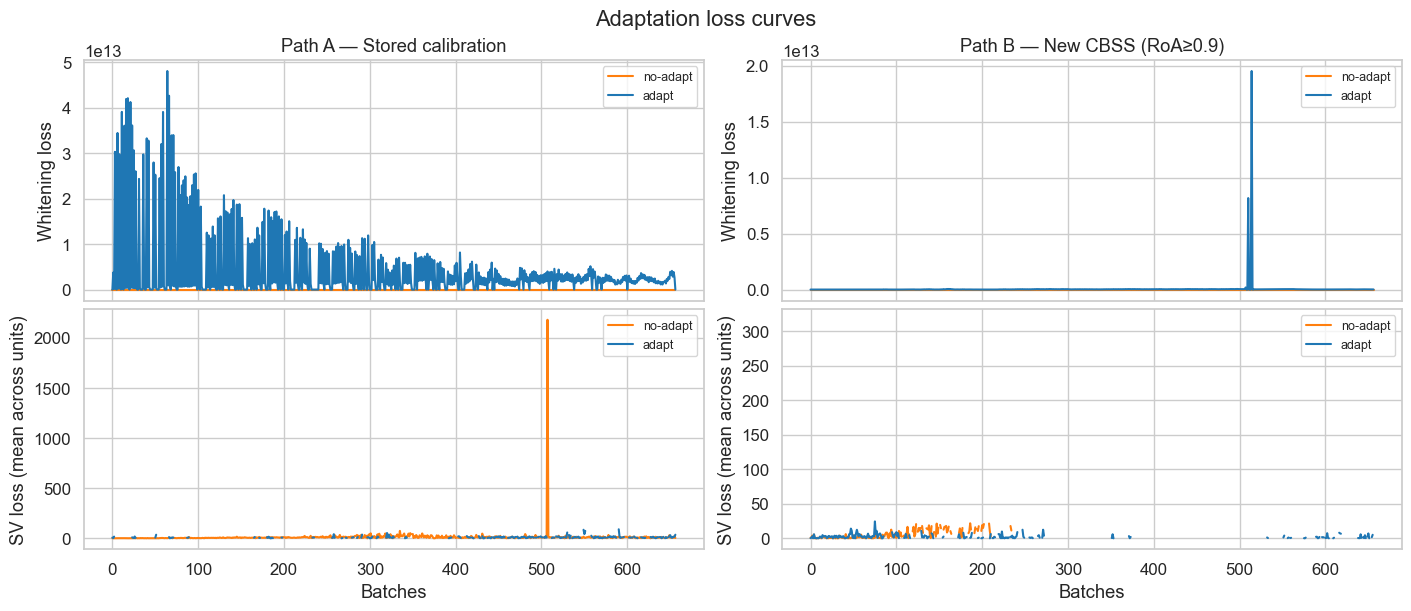

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), layout='constrained', sharex='col')

for col, (out_no, out_ad, title) in enumerate([
    (out_a_no, out_a, 'Path A — Stored calibration'),
    (out_b_no, out_b, f'Path B — New CBSS (RoA≥{ROA_TH})'),
]):
    axes[0, col].plot(out_no['wh_loss'].numpy()[:-1], label='no-adapt', color=COLORS['no_adapt'])
    axes[0, col].plot(out_ad['wh_loss'].numpy()[:-1], label='adapt',    color=COLORS['adapt'])
    axes[0, col].set(ylabel='Whitening loss', title=title)
    axes[0, col].legend(fontsize=9)

    sv_no = np.nanmean(out_no['sv_loss'].numpy(), axis=1)
    sv_ad = np.nanmean(out_ad['sv_loss'].numpy(), axis=1)
    axes[1, col].plot(sv_no[:-1], label='no-adapt', color=COLORS['no_adapt'])
    axes[1, col].plot(sv_ad[:-1], label='adapt',    color=COLORS['adapt'])
    axes[1, col].set(xlabel='Batches', ylabel='SV loss (mean across units)')
    axes[1, col].legend(fontsize=9)

plt.suptitle('Adaptation loss curves')
plt.show()

### 4.2 SV loss per unit

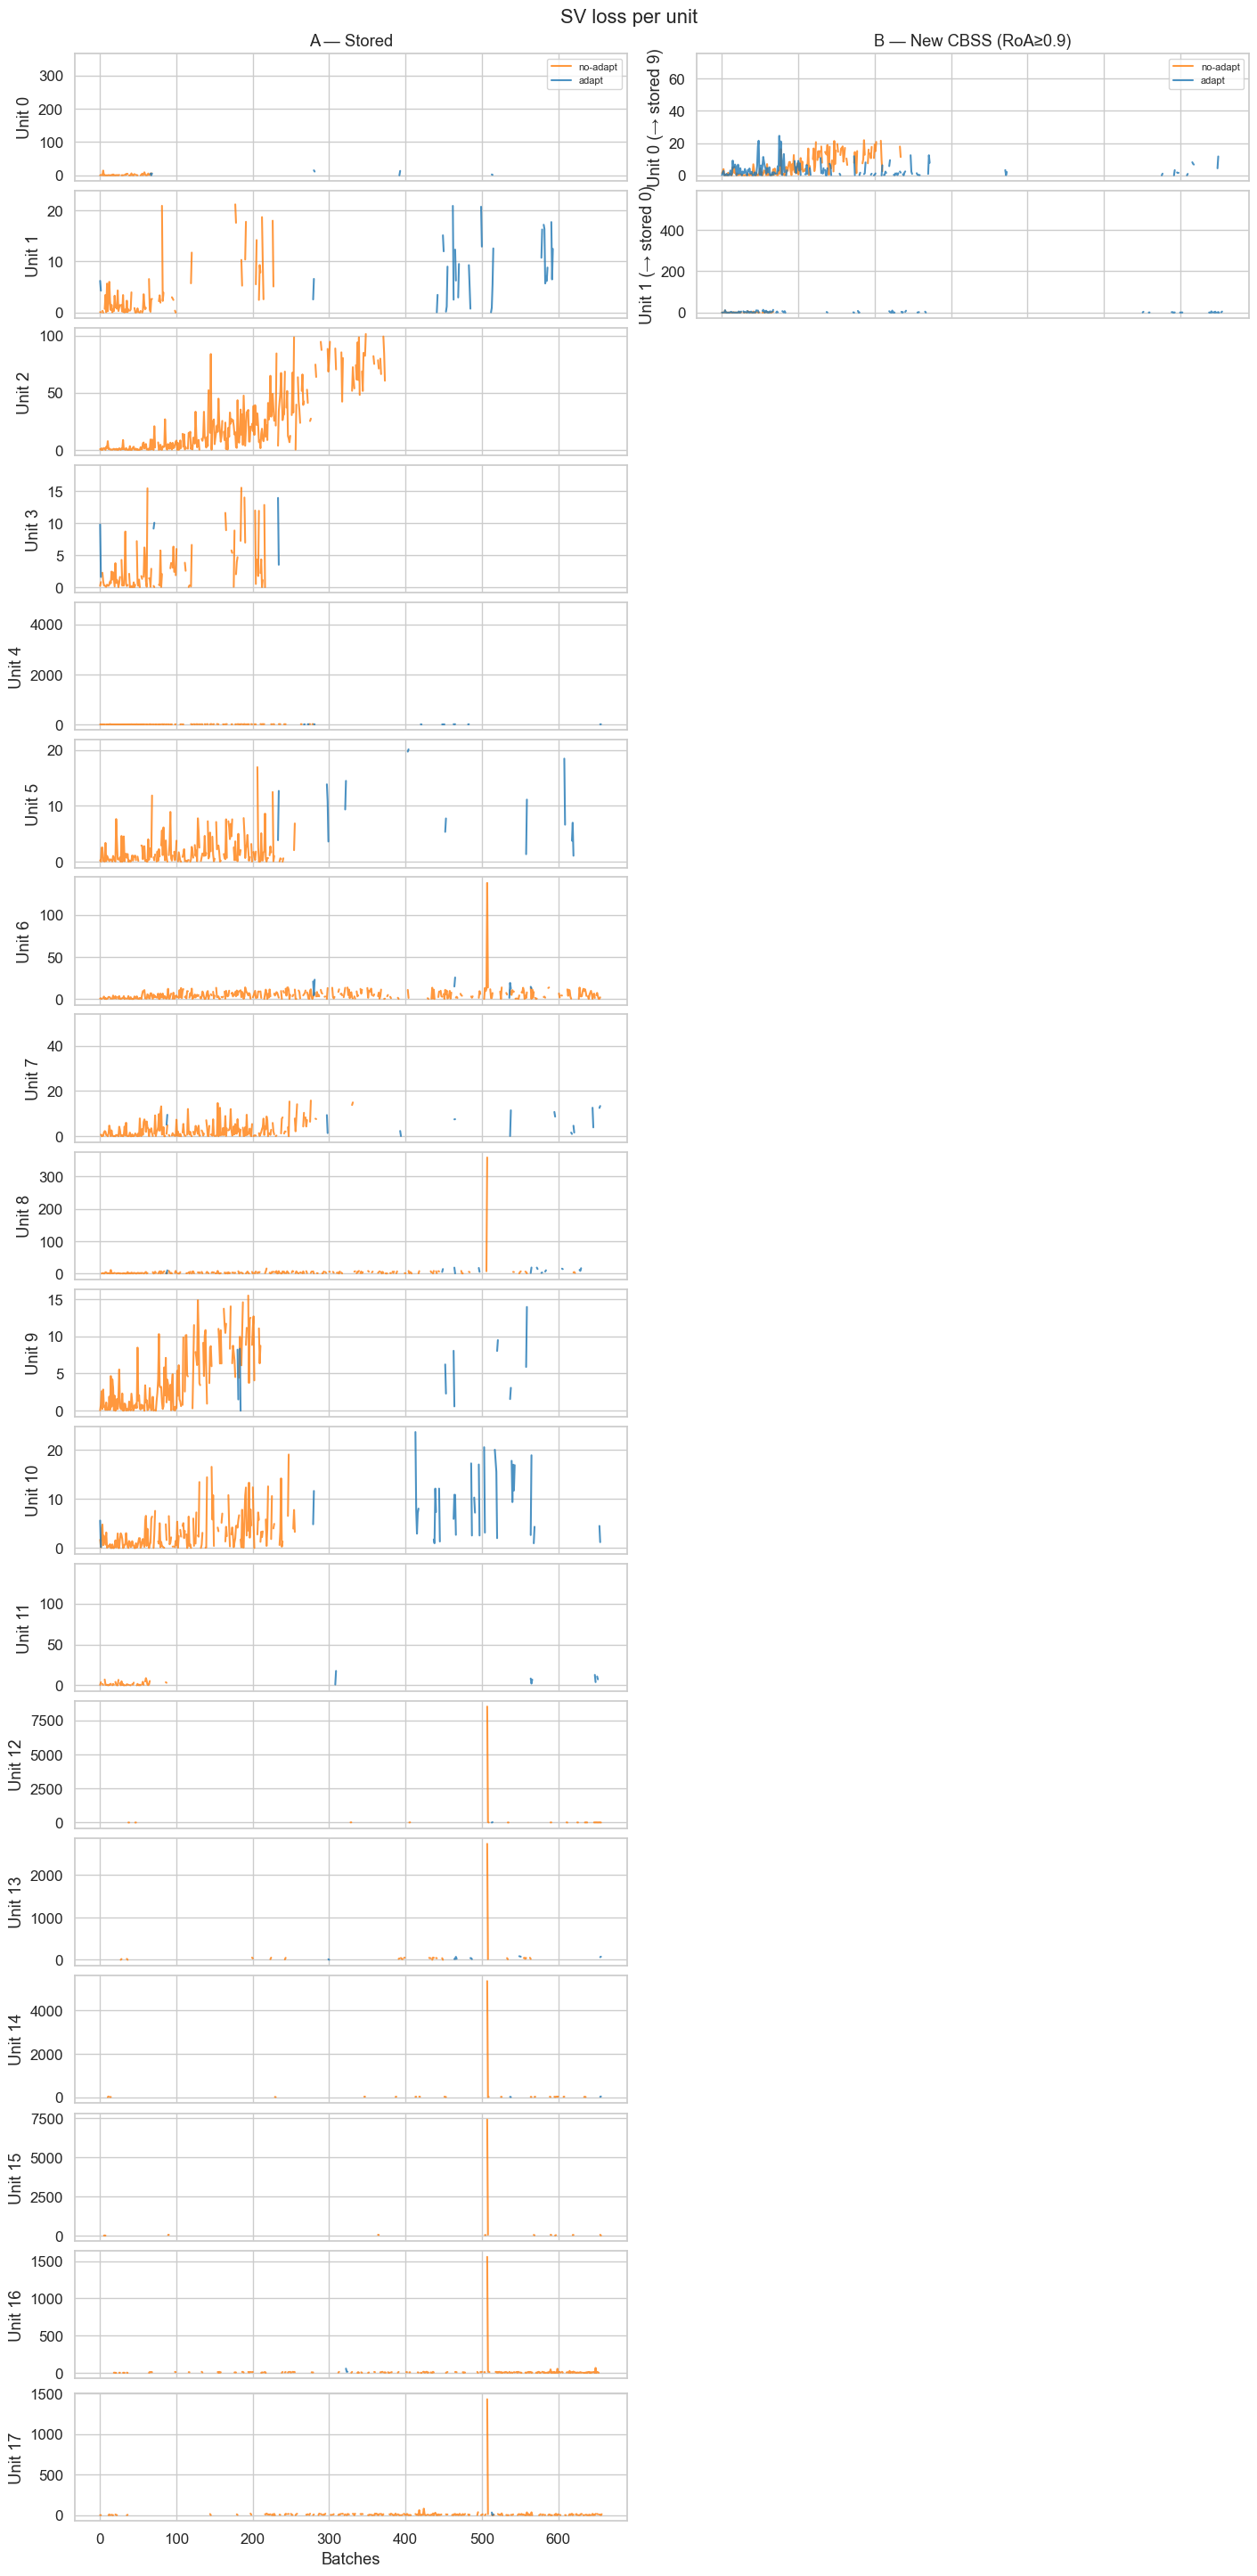

In [24]:
n_a = out_a['ipts'].shape[1]
n_b = out_b['ipts'].shape[1]
n_rows = max(n_a, n_b)

fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 1.6), layout='constrained', sharex=True)
if n_rows == 1:
    axes = axes[np.newaxis, :]

for col, (out_no, out_ad, n_units, title) in enumerate([
    (out_a_no, out_a, n_a, 'A — Stored'),
    (out_b_no, out_b, n_b, f'B — New CBSS (RoA≥{ROA_TH})'),
]):
    for i in range(n_rows):
        ax = axes[i, col]
        if i >= n_units:
            ax.set_visible(False)
            continue
        ax.plot(out_no['sv_loss'][:, i].numpy(), label='no-adapt', color=COLORS['no_adapt'], alpha=0.8)
        ax.plot(out_ad['sv_loss'][:, i].numpy(), label='adapt',    color=COLORS['adapt'],    alpha=0.8)
        gt_lbl = ''
        if col == 1 and selected.gt_matched_indices is not None:
            gt_lbl = f' (→ stored {selected.gt_matched_indices[i]})'
        ax.set(ylabel=f'Unit {i}{gt_lbl}')
        if i == 0:
            ax.set_title(title)
            ax.legend(fontsize=8)

axes[-1, 0].set(xlabel='Batches')
axes[-1, 1].set(xlabel='Batches')
plt.suptitle('SV loss per unit')
plt.show()

### 4.3 Spike trains — visualisation across recording

Plot IPT² and detected spikes for both paths (no-adapt vs. adapt) over the full recording.

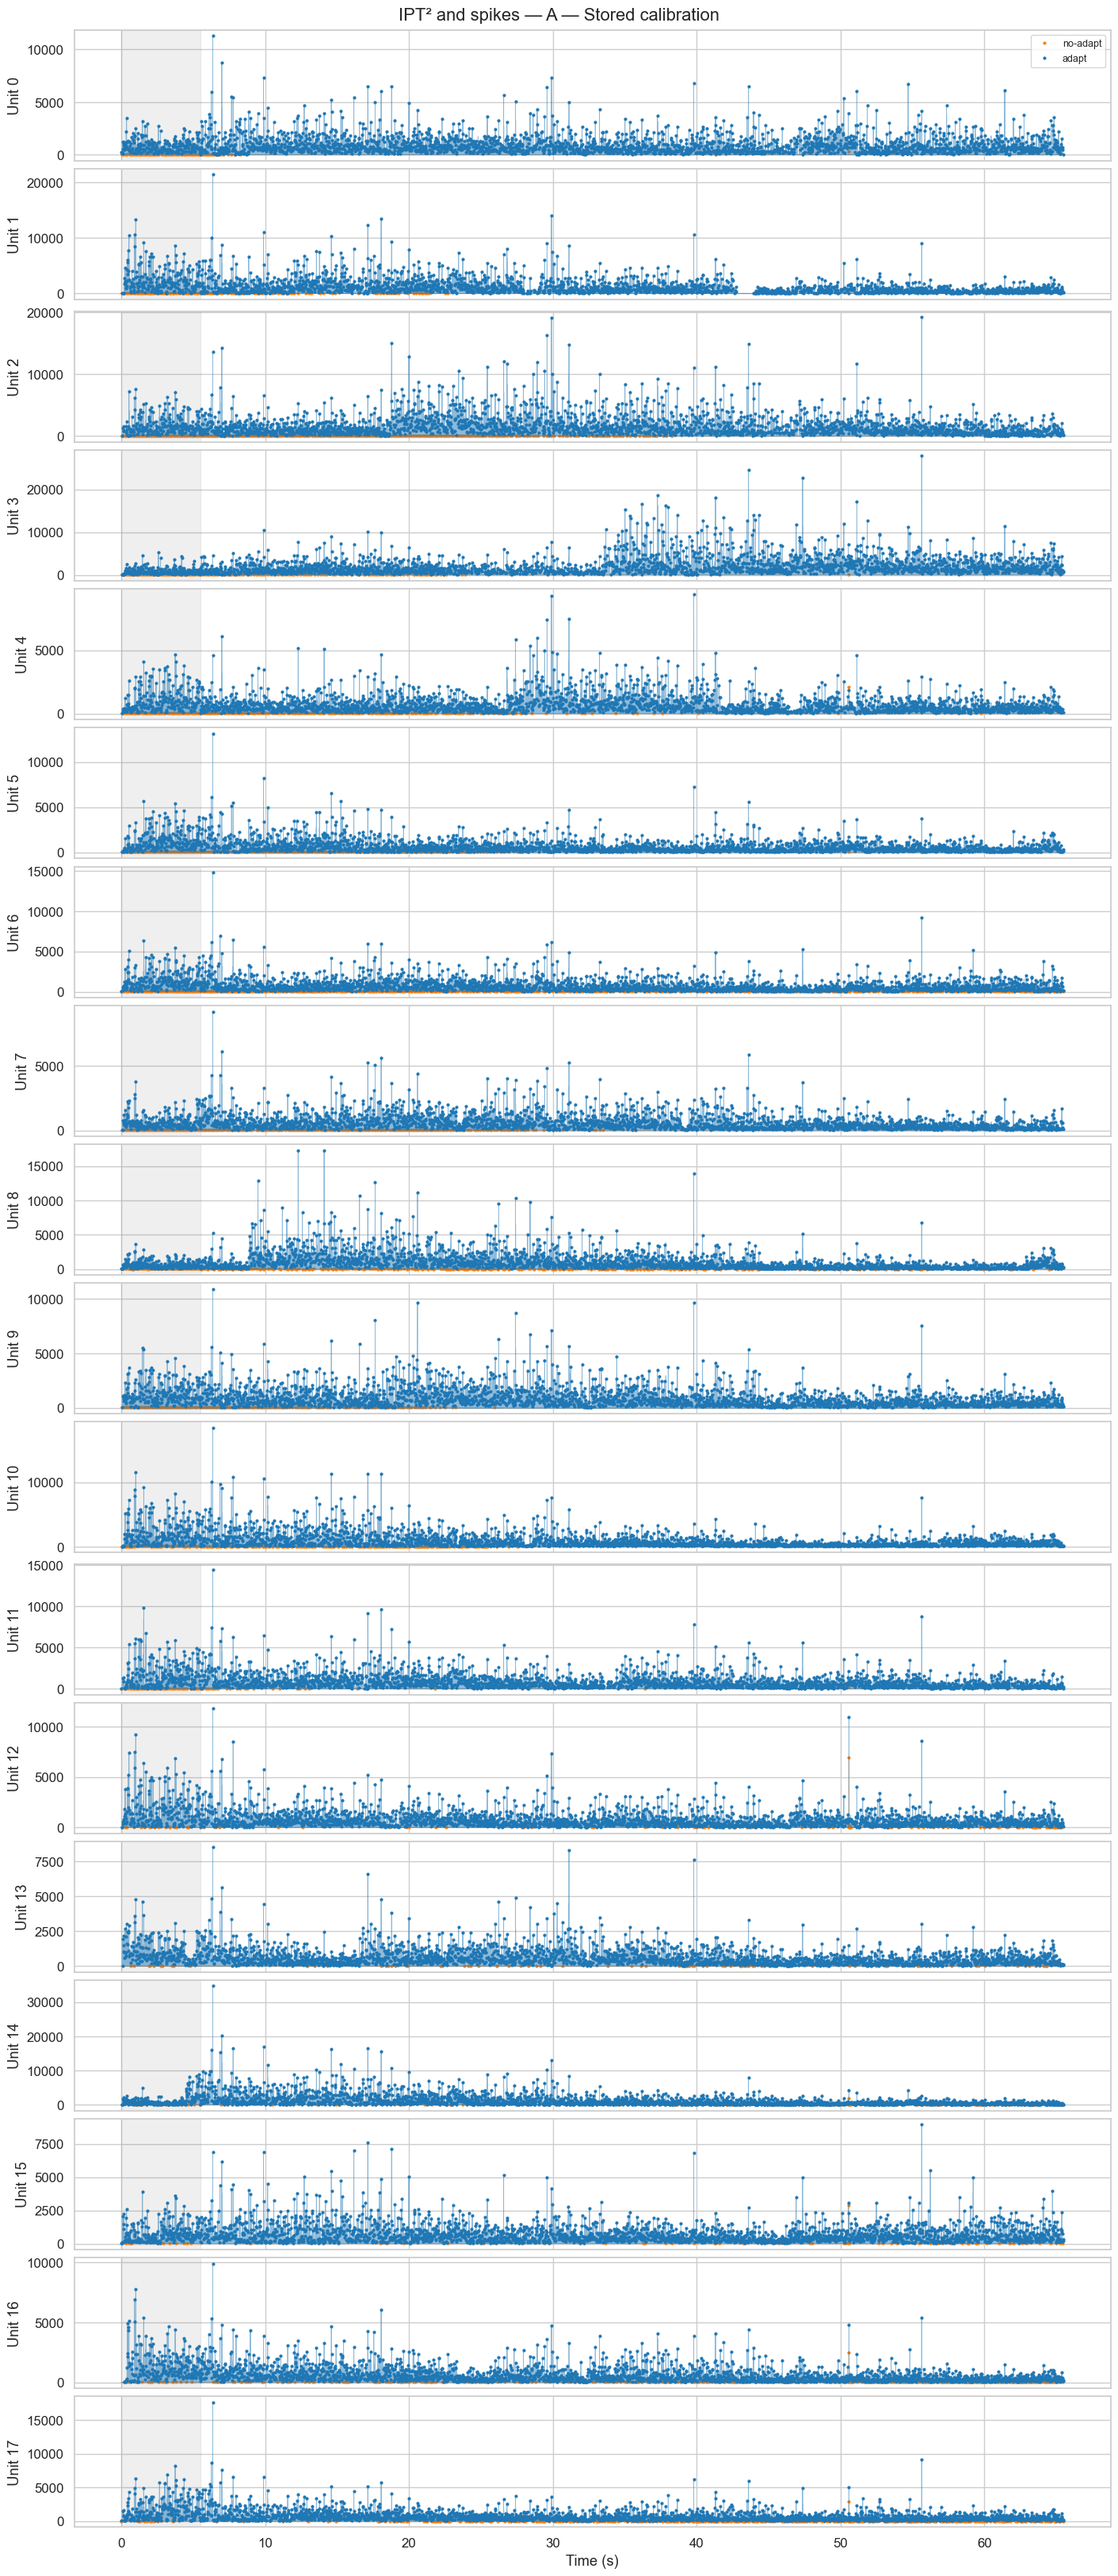

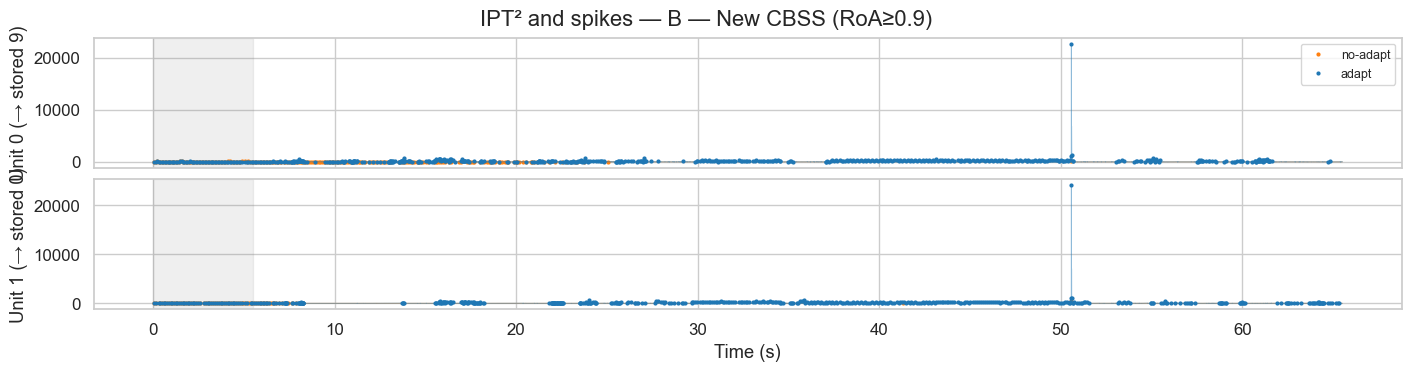

In [25]:
t0_s, t1_s = 0, n_samples / fs
idxs = np.arange(int(t0_s * fs), int(t1_s * fs))

for path_lbl, out_no, out_ad, n_units in [
    ('A — Stored calibration', out_a_no, out_a, n_a),
    (f'B — New CBSS (RoA≥{ROA_TH})', out_b_no, out_b, n_b),
]:
    fig, axes = plt.subplots(n_units, 1, figsize=(14, n_units * 1.8),
                             layout='constrained', sharex=True)
    if n_units == 1:
        axes = [axes]

    for u in range(n_units):
        ax = axes[u]
        for out, lbl, col in [
            (out_no, 'no-adapt', COLORS['no_adapt']),
            (out_ad, 'adapt',    COLORS['adapt']),
        ]:
            ipt2 = out['ipts'][idxs, u].numpy() ** 2
            ax.plot(timestamps[idxs], ipt2, color=col, alpha=0.5, lw=0.7)
            sp_mask = out['spikes'][idxs, u].bool().numpy()
            ax.plot(timestamps[idxs][sp_mask], ipt2[sp_mask], '.', color=col, markersize=4,
                    label=lbl if u == 0 else None)

        gt_lbl = ''
        if path_lbl.startswith('B') and selected.gt_matched_indices is not None:
            gt_lbl = f' (→ stored {selected.gt_matched_indices[u]})'
        ax.set(ylabel=f'Unit {u}{gt_lbl}')

    axes[0].legend(loc='upper right', fontsize=9)
    axes[-1].set(xlabel='Time (s)')

    # shade the iso calibration window
    for ax in axes:
        ax.axvspan(timestamps[py_start], timestamps[py_end - 1],
                   alpha=0.12, color='grey', label='iso calib')

    plt.suptitle(f'IPT² and spikes — {path_lbl}')
    plt.show()

### 4.4 Summary statistics

In [26]:
def spikes_per_unit(out):
    return out['spikes'].sum(0).numpy().astype(float)

sp_a_no = spikes_per_unit(out_a_no)
sp_a    = spikes_per_unit(out_a)
sp_b_no = spikes_per_unit(out_b_no)
sp_b    = spikes_per_unit(out_b)

print('Total detected spikes (full recording)')
print(f'  A no-adapt:  {sp_a_no.sum():.0f}  (per unit: {sp_a_no.mean():.0f} ± {sp_a_no.std():.0f})')
print(f'  A adapt:     {sp_a.sum():.0f}  (per unit: {sp_a.mean():.0f} ± {sp_a.std():.0f})')
print(f'  B no-adapt:  {sp_b_no.sum():.0f}  (per unit: {sp_b_no.mean():.0f} ± {sp_b_no.std():.0f})')
print(f'  B adapt:     {sp_b.sum():.0f}  (per unit: {sp_b.mean():.0f} ± {sp_b.std():.0f})')

print('\nMean whitening loss')
print(f'  A no-adapt:  {out_a_no["wh_loss"].mean().item():.4f}')
print(f'  A adapt:     {out_a["wh_loss"].mean().item():.4f}')
print(f'  B no-adapt:  {out_b_no["wh_loss"].mean().item():.4f}')
print(f'  B adapt:     {out_b["wh_loss"].mean().item():.4f}')

print('\nMedian SV loss (across units and batches)')
for lbl, out in [('A no-adapt', out_a_no), ('A adapt', out_a),
                 ('B no-adapt', out_b_no), ('B adapt', out_b)]:
    print(f'  {lbl:<14}: {np.nanmedian(out["sv_loss"].numpy()):.4f}')

Total detected spikes (full recording)
  A no-adapt:  4123  (per unit: 229 ± 146)
  A adapt:     52124  (per unit: 2896 ± 66)
  B no-adapt:  284  (per unit: 142 ± 65)
  B adapt:     1167  (per unit: 584 ± 44)

Mean whitening loss
  A no-adapt:  18250.9688
  A adapt:     4382305026048.0000
  B no-adapt:  18090.6211
  B adapt:     60470448128.0000

Median SV loss (across units and batches)
  A no-adapt    : 3.5195
  A adapt       : 7.3431
  B no-adapt    : 1.9934
  B adapt       : 1.2475


## 5. Summary

| | Path A (stored) | Path B (new CBSS) |
|--|--|--|
| **Calibration** | Loaded from `.h5` | `calibrate_from_indices()` |
| **Unit selection** | All stored units | `select_units_supervised(roa_th=0.9)` |
| **GT matching** | N/A | `gt_matched_indices` ↦ stored unit index |
| **AdaptDecomp** | `AdaptDecomp(...)` | `AdaptDecomp.from_calibration(...)` |
| **# units** | `stored['sources'].shape[1]` | `selected.sources.shape[1]` |